c:\Users\L03555197\Dropbox\Mathematics\Teaching\Tec\Learning\Python Projects\TensorCollab\venv\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - mae: 0.0553 
✅ Pérdida en test (MSE): 0.004775
📏 MAE (Error absoluto medio): 0.056245


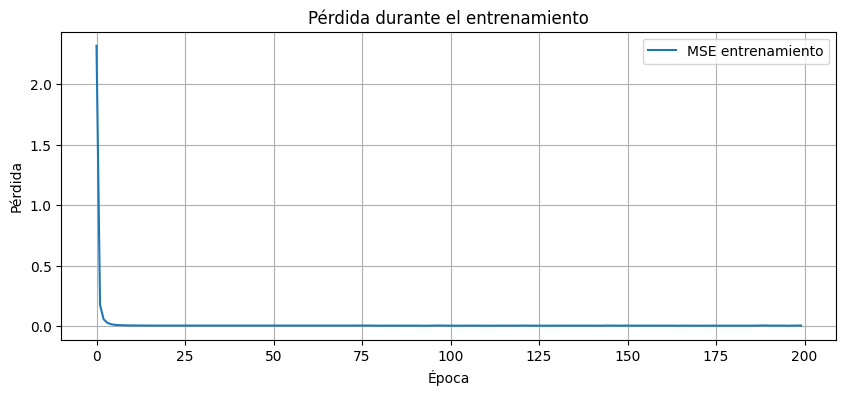

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


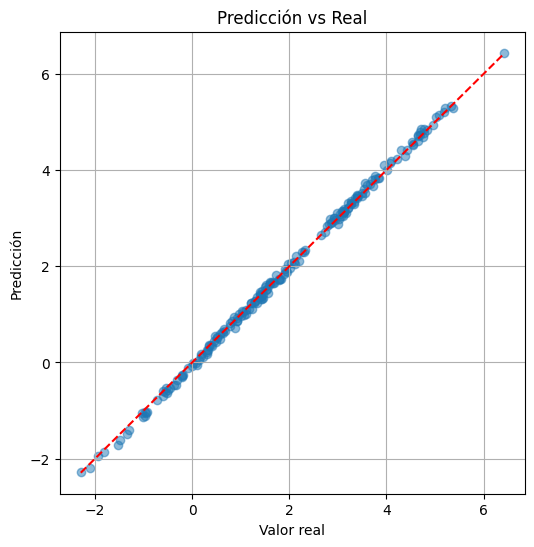

In [7]:
# Paso 1: Importar librerías necesarias
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Paso 2: Generar datos sintéticos
np.random.seed(42)
n = 1000
X1 = np.random.rand(n)
X2 = np.random.rand(n)
X3 = np.random.rand(n)

# Crear relación lineal exacta con poco ruido
Y = 5 * X1 - 3 * X2 + 2 * X3 + np.random.normal(0, 0.05, n)

X = np.stack((X1, X2, X3), axis=1)

# Paso 3: Dividir y normalizar
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Paso 4: Definir modelo de red neuronal más robusto
modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)  # salida lineal
])

modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                loss='mse', metrics=['mae'])

# Paso 5: Entrenar modelo
historial = modelo.fit(X_train, y_train, epochs=200, verbose=0)

# Paso 6: Evaluar el modelo
loss, mae = modelo.evaluate(X_test, y_test)
print(f"✅ Pérdida en test (MSE): {loss:.6f}")
print(f"📏 MAE (Error absoluto medio): {mae:.6f}")

# Paso 7: Graficar pérdida
plt.figure(figsize=(10,4))
plt.plot(historial.history['loss'], label="MSE entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Pérdida durante el entrenamiento")
plt.legend()
plt.grid(True)
plt.show()

# Paso 8: Comparar reales vs predichos
y_pred = modelo.predict(X_test).flatten()
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Predicción vs Real")
plt.grid(True)
plt.show()

ValueError: x and y must be the same size

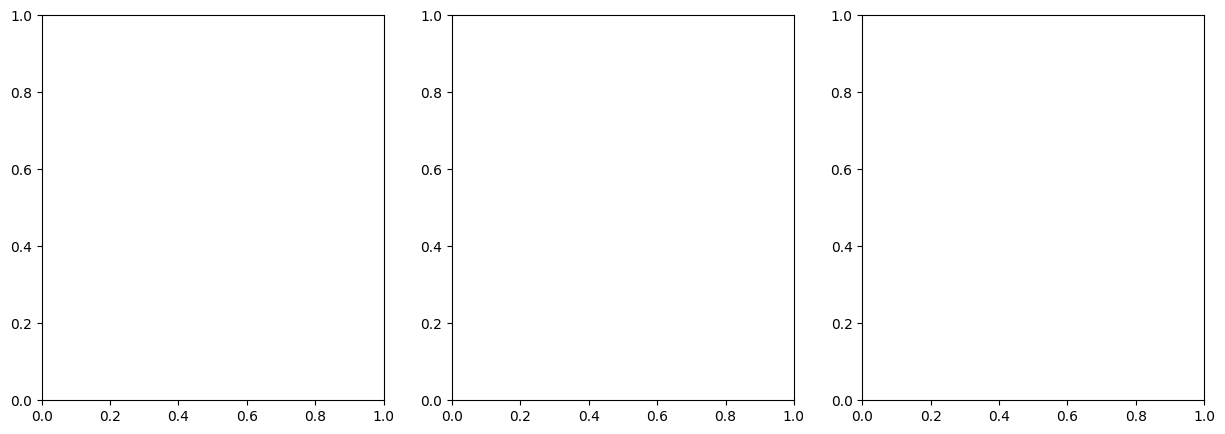

In [12]:
fig, (ax1,ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
scatter_plot1 = ax1.scatter(X[:][0], Y, label='X0', alpha=0.5)
scatter_plot2 = ax2.scatter(X[:][1], Y, label='X1', alpha=0.5)
scatter_plot3 = ax3.scatter(X[:][2], Y, label='X2', alpha=0.5)
ax1.set_title('X0 vs Predicción')
ax2.set_title('X1 vs Predicción')
ax3.set_title('X2 vs Predicción')
ax1.set_xlabel('X0')
ax2.set_xlabel('X1')
ax3.set_xlabel('X2')
ax1.set_ylabel('Predicción')
ax2.set_ylabel('Predicción')
ax3.set_ylabel('Predicción')
ax1.legend()
ax2.legend()
ax3.legend()
plt.tight_layout()
plt.show()

In [ ]:
X[0]

array([0.37454012, 0.18513293, 0.26170568])

In [ ]:
Y

array([ 1.89370999e+00,  3.65267659e+00,  2.88781983e+00,  1.22741238e+00,
       -1.03509359e+00,  3.35481553e-01, -9.05395805e-01,  3.34388431e+00,
        2.29849159e+00,  3.06766303e+00, -5.44947229e-01,  1.94421813e+00,
        3.06679213e+00,  1.27754028e+00, -1.74222487e-01, -9.59844812e-01,
        1.64738176e+00,  2.63424526e+00, -5.98919228e-01,  2.74367772e+00,
        2.88599763e+00,  8.98344283e-01,  5.69180492e-01, -9.51760624e-01,
        3.41007033e-01,  3.09597770e+00, -1.44105545e-01,  1.93381579e+00,
        2.49715829e+00, -9.33131131e-01,  3.27470867e+00,  1.46613946e-01,
        5.80285821e-01,  6.32430507e+00,  5.81599496e+00,  2.61420839e+00,
        7.20115489e-01, -1.42965774e+00,  3.72023989e+00,  1.80858724e+00,
        6.00640020e-01,  1.17968509e+00,  1.87640457e-01,  2.86596443e+00,
        3.52074152e-01,  2.83816820e+00,  9.48920689e-01,  3.89261009e+00,
        1.22069458e+00,  1.02738195e+00,  3.10433253e+00,  3.26708633e+00,
        2.18450669e+00,  

In [ ]:
X

array([[0.37454012, 0.18513293, 0.26170568],
       [0.95071431, 0.54190095, 0.2469788 ],
       [0.73199394, 0.87294584, 0.90625458],
       ...,
       [0.13681863, 0.06895802, 0.30978786],
       [0.95023735, 0.05705472, 0.29004553],
       [0.44600577, 0.28218707, 0.87141403]])

In [13]:
X[:][0]

array([0.37454012, 0.18513293, 0.26170568])